In [1]:
#Importing the necessary libraries
import pandas as pd
import numpy as np
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Reading the dataset into required data structure
zoo = pd.read_csv(r"C:\Users\Lenovo\Downloads\KNN\KNN\Zoo.csv")
zoo

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
97,wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
98,wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
99,worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7


In [3]:
zoo.shape,zoo.columns

((101, 18),
 Index(['animal name', 'hair', 'feathers', 'eggs', 'milk', 'airborne',
        'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous',
        'fins', 'legs', 'tail', 'domestic', 'catsize', 'type'],
       dtype='object'))

In [4]:
zoo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [5]:
zoo.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


In [6]:
#about the dataset:
# animal name: Name of the animal (object data type).
# hair: Indicates if the animal has hair (likely binary, where 0 = No, 1 = Yes).
# feathers: Indicates if the animal has feathers (binary).
# eggs: Indicates if the animal lays eggs (binary).
# milk: Indicates if the animal produces milk (binary).
# airborne: Indicates if the animal can fly or is airborne (binary).
# aquatic: Indicates if the animal lives in water (binary).
# predator: Indicates if the animal is a predator (binary).
# toothed: Indicates if the animal has teeth (binary).
# backbone: Indicates if the animal has a backbone (binary).
# breathes: Indicates if the animal breathes (binary).
# venomous: Indicates if the animal is venomous (binary).
# fins: Indicates if the animal has fins (binary).
# legs: Number of legs the animal has (integer).
# tail: Indicates if the animal has a tail (binary).
# domestic: Indicates if the animal is domesticated (binary).
# catsize: Indicates if the animal is roughly the size of a cat (binary).
# type: Likely a classification label indicating the type of animal (integer).

In [7]:
#Checking for duplicate values
zoo[zoo.duplicated()]

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type


In [8]:
#There are no duplicate values

In [9]:
zoo['animal name'].value_counts()

animal name
frog        2
pony        1
sealion     1
seal        1
seahorse    1
           ..
gorilla     1
goat        1
gnat        1
girl        1
wren        1
Name: count, Length: 100, dtype: int64

In [10]:
#Checking for null/missing values
zoo.isnull().sum()
#There are no null values

animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64

In [11]:
#Analyzing the data using visualizations

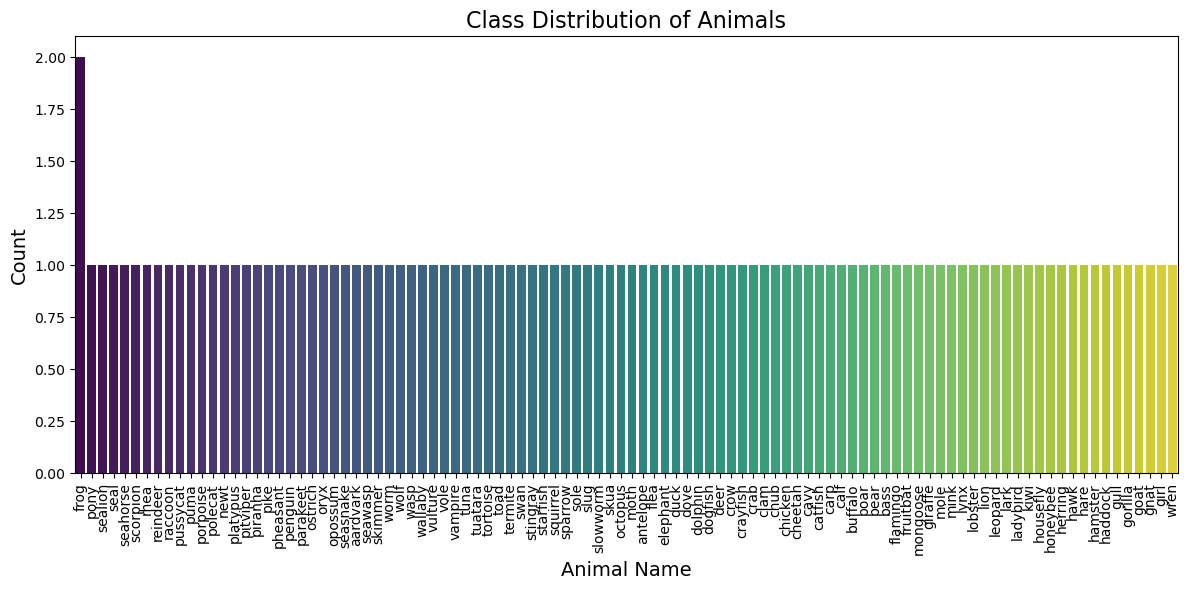

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
# Plot class distribution 
plt.figure(figsize=(12, 6))  # Adjust figure size for better clarity
sns.countplot(data=zoo, x='animal name', palette='viridis', order=zoo['animal name'].value_counts().index)
plt.xticks(rotation=90, fontsize=10)  # Rotate x-axis labels for readability
plt.title('Class Distribution of Animals', fontsize=16)
plt.xlabel('Animal Name', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.tight_layout()  # Adjust layout to avoid label overlap
plt.show()

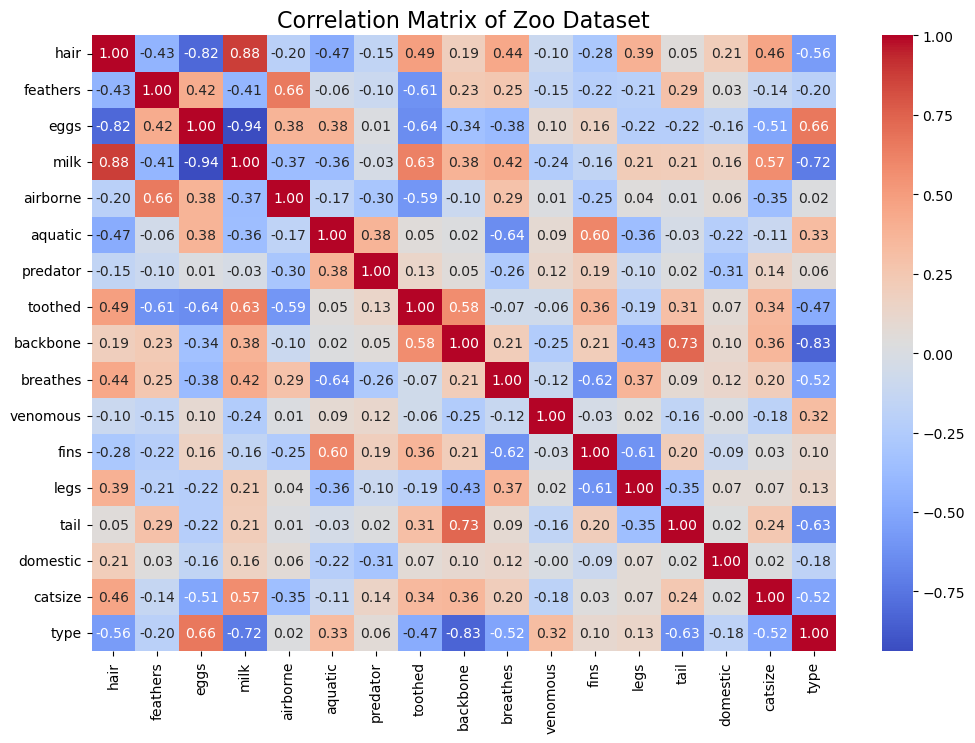

In [13]:
# Calculating the correlation matrix
corr = zoo.select_dtypes(include=[np.number]).corr()

# Visualizing the correlation matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix of Zoo Dataset', fontsize=16)
plt.show()

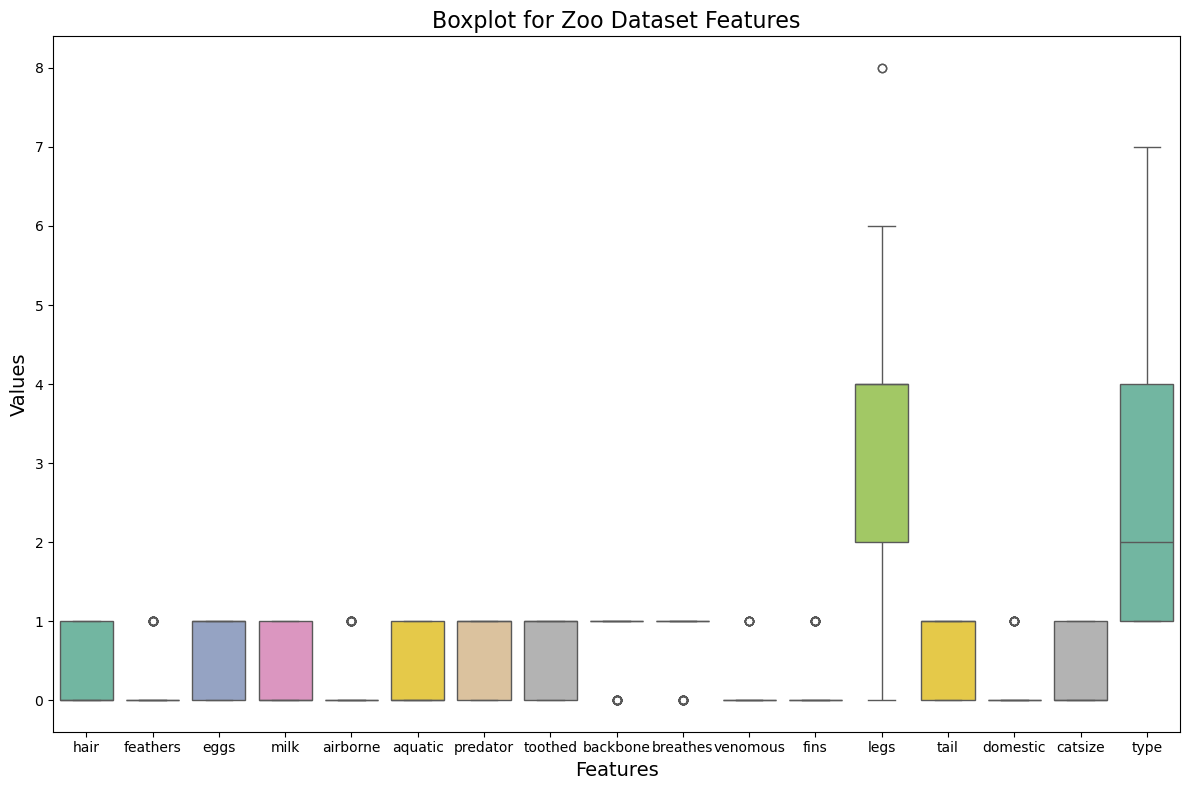

In [14]:
# Plotting boxplots for all features
plt.figure(figsize=(12, 8))  # Adjust figure size
sns.boxplot(data=zoo, orient='v', palette='Set2')  # Vertical boxplot
plt.title('Boxplot for Zoo Dataset Features', fontsize=16)
plt.ylabel('Values', fontsize=14)  # Y-axis becomes 'Values'
plt.xlabel('Features', fontsize=14)  # X-axis becomes 'Features'
plt.tight_layout()  # Adjust layout for better visualization
plt.show()

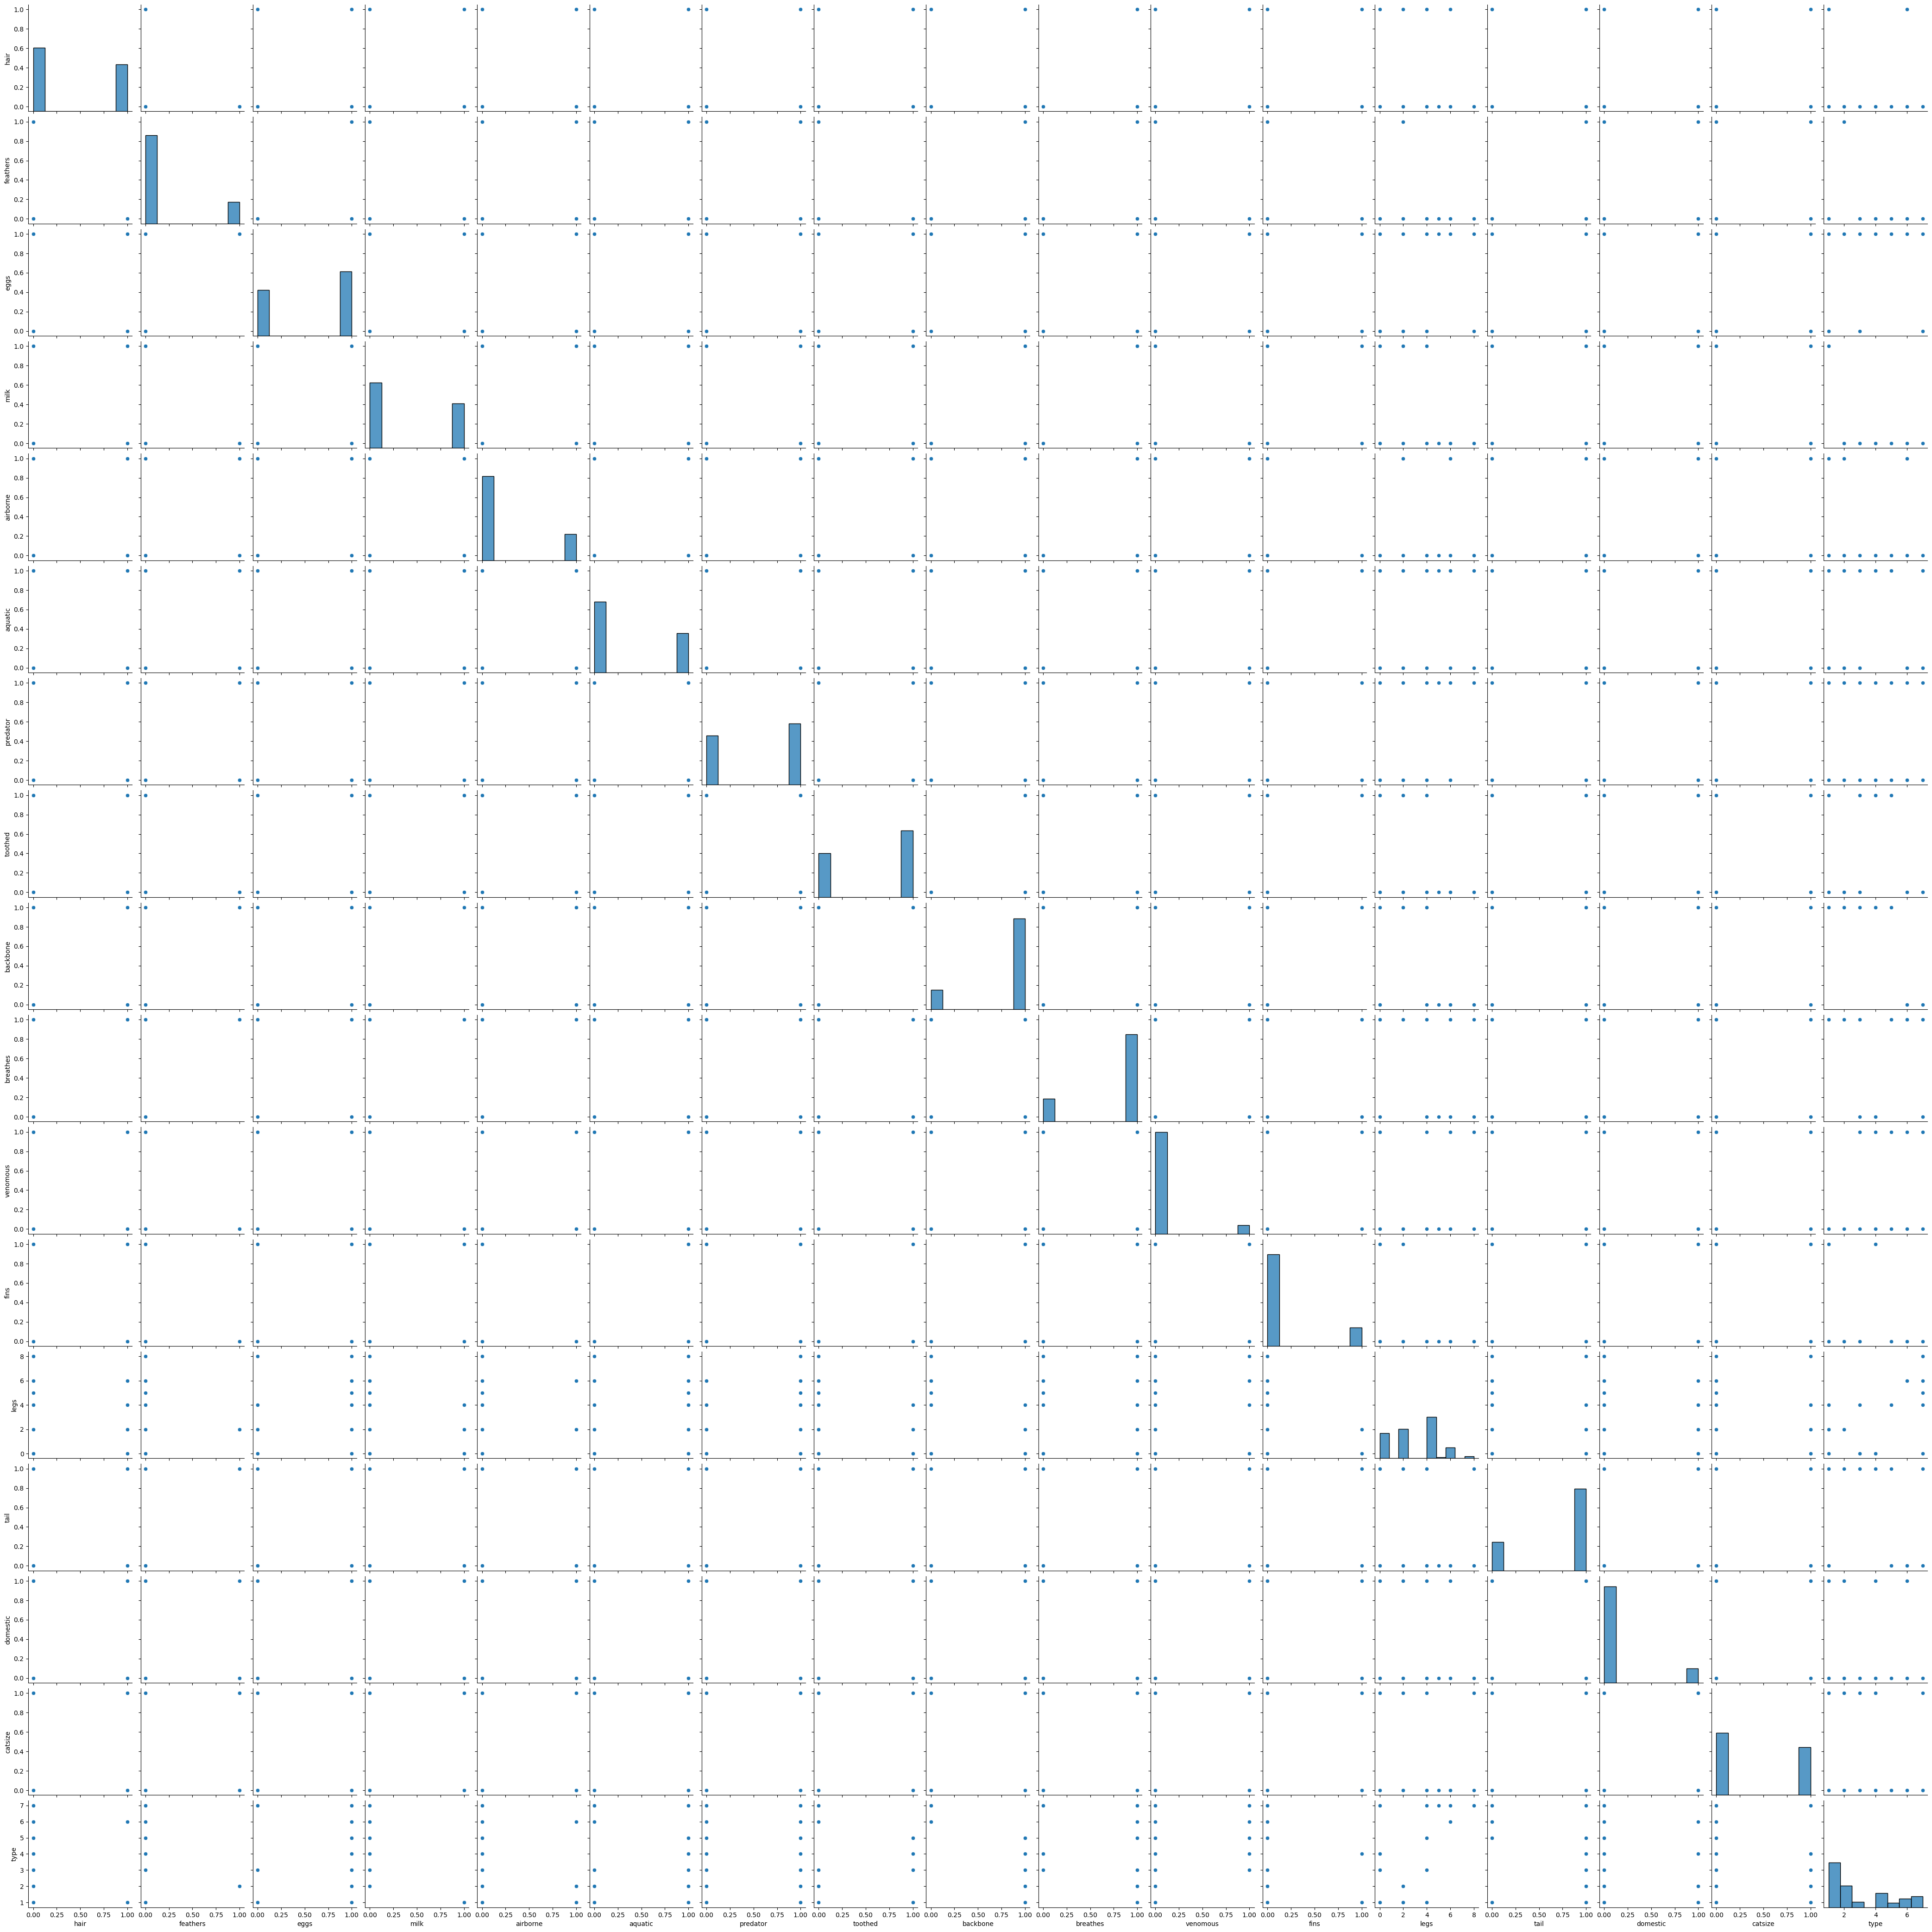

In [15]:
sns.pairplot(zoo)
plt.show()

In [16]:
#Dropping animal name column as it is categorical does not contribute to KNN algm
zoo = zoo.drop('animal name', axis=1)
zoo.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [17]:
# Handle missing values
zoo.fillna(zoo.mean(), inplace=True)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [19]:
X = zoo.drop('type', axis=1)
y = zoo['type']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [23]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [24]:
y_pred = knn.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 6, 1, 1, 1, 1, 4, 6, 6, 2, 7, 1, 1, 2, 4, 1, 4],
      dtype=int64)

In [25]:
print("Accuracy Score :",accuracy_score(y_test, y_pred))

Accuracy Score : 0.9523809523809523


In [26]:
from sklearn.model_selection import GridSearchCV

In [27]:
#set up a robust grid search to fine-tune the hyperparameters of the K-Nearest Neighbours (KNN) classifier
param_grid = {
    'n_neighbors': np.arange(1,101),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 1200 candidates, totalling 6000 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 8, 'p': 1, 'weights': 'distance'}
Best Score: 0.9875


In [28]:
knn = KNeighborsClassifier(n_neighbors=1, p=1,weights='uniform',metric='euclidean')
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=1, p=1)

In [29]:
y_pred = knn.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 6, 1, 1, 1, 1, 4, 6, 6, 2, 5, 1, 1, 2, 4, 1, 3],
      dtype=int64)

In [30]:
print("Accuracy Score :",accuracy_score(y_test, y_pred))

Accuracy Score : 0.9523809523809523


In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         2
           5       0.00      0.00      0.00         0
           6       1.00      1.00      1.00         3
           7       0.00      0.00      0.00         1

    accuracy                           0.95        21
   macro avg       0.71      0.71      0.71        21
weighted avg       0.95      0.95      0.95        21



In [32]:
from sklearn.decomposition import PCA

In [33]:
#applies Principal Component Analysis (PCA) to reduce the dimensionality of your dataset to 3 components
pca = PCA(n_components=3)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [34]:
knn = KNeighborsClassifier(n_neighbors=1, p=1,weights='uniform',metric='euclidean')
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=1, p=1)

In [79]:
#Visualize decision boundaries 
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
z_min, z_max = X_train[:, 2].min() - 1, X_train[:, 2].max() + 1

xx, yy, zz = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100),
                         np.linspace(z_min, z_max, 100))

grid = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]
preds = knn.predict(grid).reshape(xx.shape)

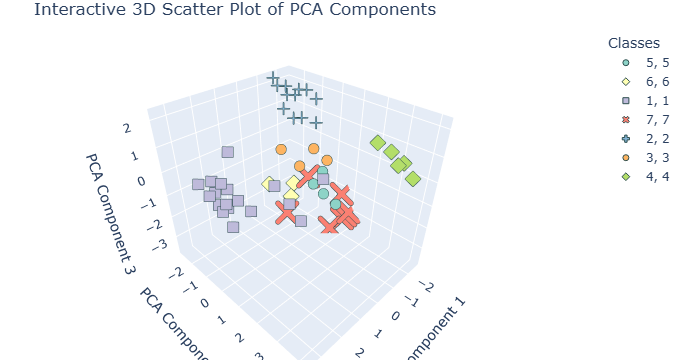

In [85]:
# Creating an enhanced 3D scatter plot
fig = px.scatter_3d(
    x=X_train[:, 0], 
    y=X_train[:, 1], 
    z=X_train[:, 2],
    color=y_train.astype(str),  # Convert y_train to string for clearer distinctions
    symbol=y_train.astype(str),  # Add symbols for better class differentiation
    title="Interactive 3D Scatter Plot of PCA Components",
    labels={'x': 'PCA Component 1', 'y': 'PCA Component 2', 'z': 'PCA Component 3'},
    color_discrete_sequence=px.colors.qualitative.Set3  # Use a visually appealing palette
)

# Update marker properties
fig.update_traces(
    marker=dict(
        size=6,  # Slightly larger points
        line=dict(width=1, color='DarkSlateGrey')  # Add an outline for clarity
    ),
    selector=dict(mode='markers')
)

# Add interactive customization
fig.update_layout(
    scene=dict(
        xaxis_title='PCA Component 1',
        yaxis_title='PCA Component 2',
        zaxis_title='PCA Component 3'
    ),
    legend=dict(title='Classes'),  # Add a meaningful legend title
    margin=dict(l=0, r=0, b=0, t=30)  # Adjust margins for better fit
)

# Display the figure
fig.show()


In [91]:
# Interview Questions:
# 1. What are the key hyperparameters in KNN?

# n_neighbors: Determines the number of nearest neighbors to consider for classification or regression. Choosing the right value (often through techniques like cross-validation) is crucial for balancing bias and variance.

# weights: Specifies the weight assigned to the neighbors. Options include:
# -'uniform': All neighbors contribute equally to the decision.
# -'distance': Neighbors closer to the query point are given more weight.

# metric: Defines the distance metric used to calculate similarity between data points. Common metrics include Euclidean, Manhattan, and Minkowski.

# p: Power parameter for Minkowski metric (p=1 for Manhattan distance, p=2 for Euclidean distance).

# algorithm: Determines how the nearest neighbors are computed:
# -'auto': Automatically chooses the best algorithm based on the dataset.
# -'ball_tree', 'kd_tree', or 'brute': Use these specific algorithms.

# leaf_size: Parameter for tree-based algorithms (BallTree and KDTree) that affects the speed and memory usage.

In [89]:
# 2. What distance metrics can be used in KNN?
# KNN relies on distance metrics to measure the similarity between data points. Common options include:

# Euclidean Distance: The straight-line distance between two points. Commonly used when features are continuous. $$\sqrt{\sum_{i=1}^n (x_i - y_i)^2}$$

# Manhattan Distance: The sum of absolute differences, ideal for high-dimensional data or grid-like data. $$\sum_{i=1}^n |x_i - y_i|$$

# Minkowski Distance: Generalized distance metric (with p as a hyperparameter): $$\left(\sum_{i=1}^n |x_i - y_i|p\right){1/p}$$

# Hamming Distance: Used for categorical data, counting the number of positions where values differ.

# Chebyshev Distance: Measures the maximum difference between coordinates.